Decoder Only Plus Ollama

In [2]:
import pandas as pd

json_file_path = '/content/filtered.json'
df_json = pd.read_json(json_file_path)
display(df_json.head())

,id,chinese,gold,human,machine
0,0,一波未平，一波又起,suffer a string of reverses,[hardly has one wave subsided when another ris...,"[One wave is not flat, another wave is rising,..."
1,1,一败涂地,suffer a crushing defeat,"[be ruined completely, utter failure, a comple...","[A crushing defeat, a total failure, A defeat]"
2,2,一般见识,lower oneself to the same level as somebody else,[],"[General knowledge, General Insight]"
3,3,一板三眼,following a prescribed pattern in speech or ac...,"[scrupulous and methodical, very careful of th...","[One board and three eyes, A board with three ..."
4,4,一本正经,put on a solemn look,"[assume a dead serious attitude, with feigned ...","[serious, in earnest, in good taste, in a seri..."


In [4]:
import pandas as pd
from sentence_transformers import SentenceTransformer

# Use the already loaded df_json
df = df_json

df['chinese_text'] = df['chinese']
df['english_text'] = df['gold']

In [5]:
!pip install ollama
import ollama
import pandas as pd
import numpy as np
from tqdm import tqdm

# Install zstd, which is required for Ollama installation
!sudo apt-get update
!sudo apt-get install -y zstd

# Install and start Ollama in the background
!curl -fsSL https://ollama.com/install.sh | sh
import os
os.environ['OLLAMA_HOST'] = '127.0.0.1:11434'

# Start Ollama in the background
import subprocess
import time

process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
print("Ollama server starting...")
time.sleep(5) # Give the server a few seconds to start
print("Ollama server started.")

# Pull the specific model
model_name = "qwen2.5:0.5b"
print(f"Pulling Ollama model: {model_name}...")
!ollama pull {model_name}
print(f"Model {model_name} pulled.")

# Load df_json directly in this cell to ensure it's defined
json_file_path = '/content/filtered.json'
df_json = pd.read_json(json_file_path)

# Take a smaller sample to speed up execution for now
sample_size = 100 # You can adjust this number or remove for full dataset
df = df_json.sample(n=sample_size, random_state=42)

df['chinese_text'] = df['chinese']
df['english_text'] = df['gold']

def get_ollama_embeddings(texts, model="qwen2.5:0.5b"):
    embeddings = []


    for text in tqdm(texts, desc="Generating Embeddings"):

        response = ollama.embeddings(model=model, prompt=text)
        embeddings.append(response["embedding"])
    return np.array(embeddings)

# Generate
print("Generating English embeddings...")
english_embeddings = get_ollama_embeddings(df['english_text'].tolist())

print("Generating Chinese embeddings...")
chinese_embeddings = get_ollama_embeddings(df['chinese_text'].tolist()) # Changed french_text to chinese_text

# Create separate DataFrames with embeddings
english_df = pd.DataFrame({
    'text': df['english_text'],
    'language': 'English',
    'embedding': list(english_embeddings)
})

chinese_df = pd.DataFrame({
    'text': df['chinese_text'],
    'language': 'Chinese',
    'embedding': list(chinese_embeddings)
})

# Combine both DataFrames
combined_df = pd.concat([english_df, chinese_df], ignore_index=True)

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to r

Generating Embeddings: 100%|██████████| 100/100 [00:41<00:00,  2.43it/s]


Generating Chinese embeddings...


Generating Embeddings: 100%|██████████| 100/100 [00:31<00:00,  3.19it/s]


In [6]:
# Reduce embeddings to 2D using UMAP
from umap import UMAP
import numpy as np
# Reduce embeddings to 2D using UMAP
print("Reducing embeddings to 2D...")
all_embeddings = np.vstack(combined_df['embedding'].values)
reducer = UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(all_embeddings)

# Add 2D coordinates to dataframe
combined_df['x'] = embeddings_2d[:, 0]
combined_df['y'] = embeddings_2d[:, 1]

# Save to CSV for online visualization
output_df = combined_df[['text', 'language', 'x', 'y']].copy()
output_df.to_csv('embeddings_2d.csv', index=False)
print("Saved embeddings to 'embeddings_2d.csv'")

# Also save with full embeddings in parquet format
combined_df.to_parquet('embeddings_full.parquet')
print("Saved full embeddings to 'embeddings_full.parquet'")

print(f"\nDataset info: {len(output_df)} points total")
print(f"English: {len(output_df[output_df['language']=='English'])} points")
print(f"Chinese: {len(output_df[output_df['language']=='Chinese'])} points")



Reducing embeddings to 2D...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved embeddings to 'embeddings_2d.csv'
Saved full embeddings to 'embeddings_full.parquet'

Dataset info: 200 points total
English: 100 points
Chinese: 100 points


In [7]:
# Calculate distances between English and French points
english_points = embeddings_2d[:len(english_embeddings)]
chinese_points = embeddings_2d[len(english_embeddings):]

distances = []
for i in range(len(english_points)):
    dist = np.sqrt((english_points[i][0] - chinese_points[i][0])**2 +
                   (english_points[i][1] - chinese_points[i][1])**2)
    distances.append(dist)

avg_distance = np.mean(distances)

print(f"\nAverage distance between English and Chinese: {avg_distance:.4f}")
print(f"Min distance: {np.min(distances):.4f}")
print(f"Max distance: {np.max(distances):.4f}")


Average distance between English and Chinese: 15.2532
Min distance: 12.7682
Max distance: 18.3549


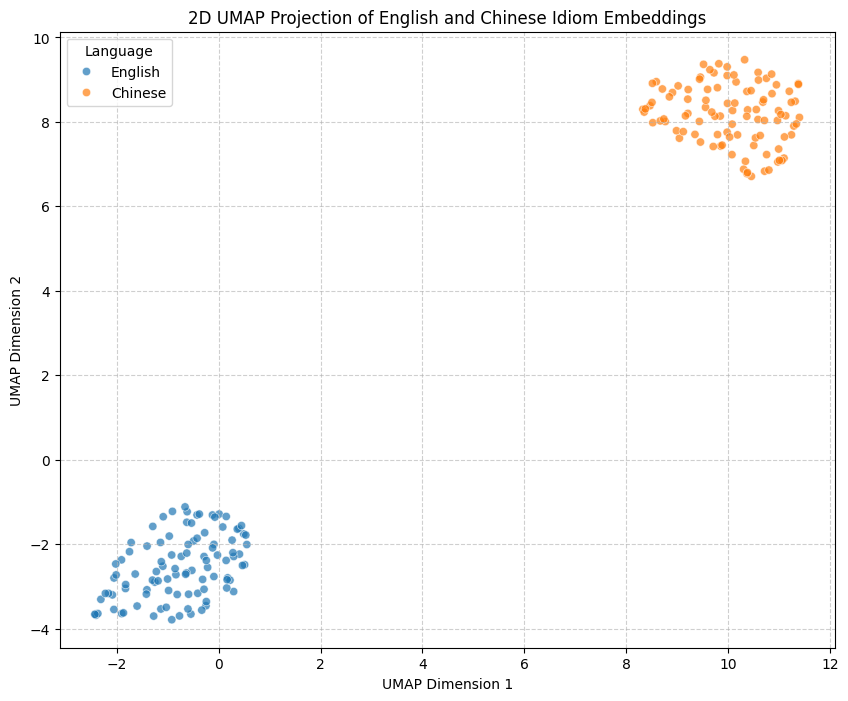

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x='x', y='y', hue='language', data=output_df, alpha=0.7)
plt.title('2D UMAP Projection of English and Chinese Idiom Embeddings')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Language')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()